# Deep Learning
# BiLSTM with Attention and GloVe

In [1]:
import os
import re
import json
import time
import random
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

Config

In [4]:
SEED = 42

# Data

TEXT_COL = "text"
LABEL_COL = "label"

# Embeddings
GLOVE_DIM = 100
GLOVE_PATH = "../data/Glove/glove.6B.100d.txt"

# Vocabulary
MIN_WORD_FREQ = 2                     # similar to  min_df=2 from the TF-IDF 
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
PAD_IDX = 0
UNK_IDX = 1

# Sequence
MAX_LEN = None                        

# Model
HIDDEN_DIM = 128                      
NUM_LAYERS = 1
DROPOUT = 0.4
FREEZE_EMBEDDINGS = True

# Training
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
MAX_EPOCHS = 20
PATIENCE = 3                          # early stopping on val F1
GRAD_CLIP = 5.0

# Artifacts
SAVE_DIR = "saved/bilstm"
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ------------------------------------------------------------------


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)
print(f"Device: {DEVICE}")
print(f"GloVe dimension: {GLOVE_DIM}")

Device: cpu
GloVe dimension: 100


In [5]:
import os
print(os.path.exists(GLOVE_PATH), GLOVE_PATH)

True ../data/Glove/glove.6B.100d.txt


In [6]:


TRAIN_PATH = "../data/processed/train.csv"   
VAL_PATH   = "../data/processed/val.csv"
TEST_PATH  = "../data/processed/test.csv"


def load_split(path, text_col, label_col):
    frame = pd.read_csv(path)
    frame[text_col] = frame[text_col].fillna("").astype(str)
    frame[label_col] = frame[label_col].astype(int)
    return frame


train_df = load_split(TRAIN_PATH, TEXT_COL, LABEL_COL)
val_df   = load_split(VAL_PATH,   TEXT_COL, LABEL_COL)
test_df  = load_split(TEST_PATH,  TEXT_COL, LABEL_COL)

for name, frame in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"{name:<6} {len(frame):>7,} rows | {frame[LABEL_COL].mean():.4f} positive")

total_rows = len(train_df) + len(val_df) + len(test_df)
print(f"\nTotal: {total_rows:,}")

# Integrity check
train_texts = set(train_df[TEXT_COL])
val_texts   = set(val_df[TEXT_COL])
test_texts  = set(test_df[TEXT_COL])

print(f"Train∩Val overlap:  {len(train_texts & val_texts):,}")
print(f"Train∩Test overlap: {len(train_texts & test_texts):,}")
print(f"Val∩Test overlap:   {len(val_texts & test_texts):,}")

Train   14,441 rows | 0.3706 positive
Val      3,094 rows | 0.3704 positive
Test     3,095 rows | 0.3706 positive

Total: 20,630
Train∩Val overlap:  0
Train∩Test overlap: 0
Val∩Test overlap:   0


Token-length percentiles (train set):
  p50:    117
  p75:    200
  p90:    347
  p95:    813
  p97:    835
  p99:  2,100
  max:  4,566
 mean:  195.5


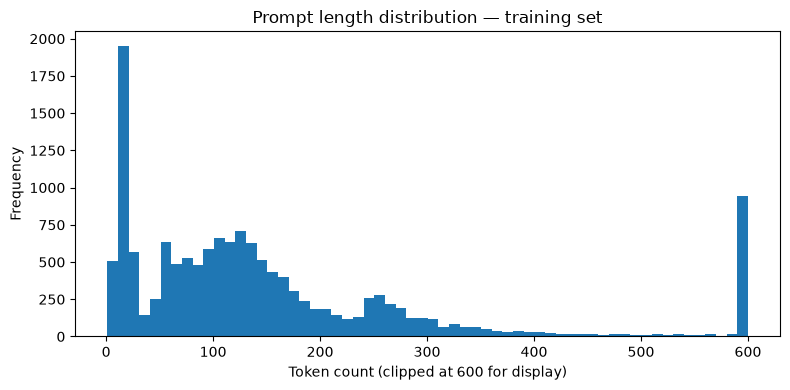

In [7]:
TOKEN_PATTERN = re.compile(r"[A-Za-z0-9']+|[^\sA-Za-z0-9]")


def tokenize(text):
    """Lowercase + regex tokenizer that keeps punctuation as separate tokens."""
    return TOKEN_PATTERN.findall(text.lower())


train_tokens = [tokenize(t) for t in train_df[TEXT_COL]]
train_lengths = np.array([len(toks) for toks in train_tokens])

percentiles = [50, 75, 90, 95, 97, 99]
print("Token-length percentiles (train set):")
for p in percentiles:
    print(f"  p{p:>2}: {int(np.percentile(train_lengths, p)):>6,}")
print(f"  max: {train_lengths.max():>6,}")
print(f" mean: {train_lengths.mean():>6.1f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.clip(train_lengths, 0, 600), bins=60)
ax.set_xlabel("Token count (clipped at 600 for display)")
ax.set_ylabel("Frequency")
ax.set_title("Prompt length distribution — training set")
plt.tight_layout()
plt.show()

Fix MAX_LEN

In [10]:
for candidate in [128, 256, 384, 512, 768, 1024]:
    cov_benign = (train_df_with_len.loc[train_df_with_len[LABEL_COL] == 0, "token_len"] <= candidate).mean()
    cov_malicious = (train_df_with_len.loc[train_df_with_len[LABEL_COL] == 1, "token_len"] <= candidate).mean()
    print(f"MAX_LEN = {candidate:>5}: benign {cov_benign:.2%} | malicious {cov_malicious:.2%}")

MAX_LEN =   128: benign 57.71% | malicious 51.76%
MAX_LEN =   256: benign 80.67% | malicious 84.38%
MAX_LEN =   384: benign 89.32% | malicious 94.08%
MAX_LEN =   512: benign 91.12% | malicious 95.57%
MAX_LEN =   768: benign 93.88% | malicious 96.38%
MAX_LEN =  1024: benign 97.59% | malicious 99.48%


In [12]:
# Percentile-based candidate
p95_len = int(np.percentile(train_lengths, 95))
print(f"p95 token length: {p95_len}")


# coverage in particular improves substantially at 512 vs 256.
MAX_LEN = 512

coverage_overall = (train_lengths <= MAX_LEN).mean()
coverage_benign = (train_df_with_len.loc[train_df_with_len[LABEL_COL] == 0, "token_len"] <= MAX_LEN).mean()
coverage_malicious = (train_df_with_len.loc[train_df_with_len[LABEL_COL] == 1, "token_len"] <= MAX_LEN).mean()

print(f"MAX_LEN = {MAX_LEN}")
print(f"Overall coverage:   {coverage_overall:.2%}")
print(f"Benign coverage:    {coverage_benign:.2%}")
print(f"Malicious coverage: {coverage_malicious:.2%}")

p95 token length: 813
MAX_LEN = 512
Overall coverage:   92.77%
Benign coverage:    91.12%
Malicious coverage: 95.57%


# Building Vocabulary using Training Data

In [13]:
counter = Counter()
for toks in train_tokens:
    counter.update(toks)

print(f"Raw vocabulary size: {len(counter):,}")

vocab = {PAD_TOKEN: PAD_IDX, UNK_TOKEN: UNK_IDX}
for word, freq in counter.most_common():
    if freq >= MIN_WORD_FREQ:
        vocab[word] = len(vocab)

VOCAB_SIZE = len(vocab)
print(f"Vocabulary after min_freq={MIN_WORD_FREQ}: {VOCAB_SIZE:,}")


def encode(tokens, vocab, max_len):
    """Map tokens -> ids, truncate to max_len, pad with PAD_IDX."""
    ids = []
    for tok in tokens[:max_len]:
        ids.append(vocab.get(tok, UNK_IDX))
    length = len(ids)
    while len(ids) < max_len:
        ids.append(PAD_IDX)
    return ids, length

Raw vocabulary size: 29,874
Vocabulary after min_freq=2: 20,610


In [16]:



def load_glove(path, dim):
    """Read a GloVe text file into {word: vector}."""
    embeddings = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            word = parts[0]
            vector = np.asarray(parts[1:], dtype=np.float32)
            if vector.shape[0] == dim:
                embeddings[word] = vector
    return embeddings


def build_embedding_matrix(vocab, glove, dim, seed):
    """Rows aligned to vocab indices. Hits copy GloVe; misses get random init."""
    rng = np.random.default_rng(seed)
    matrix = rng.normal(scale=0.1, size=(len(vocab), dim)).astype(np.float32)
    matrix[PAD_IDX] = np.zeros(dim, dtype=np.float32)

    hits = 0
    for word, idx in vocab.items():
        vector = glove.get(word)
        if vector is not None:
            matrix[idx] = vector
            hits += 1
    return matrix, hits


glove = load_glove(GLOVE_PATH, GLOVE_DIM)
print(f"GloVe vectors loaded: {len(glove):,}")

embedding_matrix, hits = build_embedding_matrix(vocab, glove, GLOVE_DIM, SEED)
print(f"Embedding matrix: {embedding_matrix.shape}")
print(f"Vocabulary coverage: {hits:,}/{VOCAB_SIZE:,} ({hits / VOCAB_SIZE:.2%})")

del glove   # free memory 

GloVe vectors loaded: 400,000
Embedding matrix: (20610, 100)
Vocabulary coverage: 15,209/20,610 (73.79%)


In [17]:
def build_embedding_matrix(vocab, glove, dim, seed):
    rng = np.random.default_rng(seed)
    matrix = rng.normal(scale=0.1, size=(len(vocab), dim)).astype(np.float32)
    matrix[PAD_IDX] = np.zeros(dim, dtype=np.float32)

    is_pretrained = np.zeros(len(vocab), dtype=bool)
    misses = []
    hits = 0

    for word, idx in vocab.items():
        vector = glove.get(word)
        if vector is not None:
            matrix[idx] = vector
            is_pretrained[idx] = True
            hits += 1
        else:
            misses.append(word)

    return matrix, is_pretrained, hits, misses


glove = load_glove(GLOVE_PATH, GLOVE_DIM)
embedding_matrix, is_pretrained, hits, misses = build_embedding_matrix(
    vocab, glove, GLOVE_DIM, SEED
)

print(f"Vocabulary coverage: {hits:,}/{VOCAB_SIZE:,} ({hits / VOCAB_SIZE:.2%})")
print(f"\nSample of OOV words ({len(misses):,} total):")
print(misses[:40])

del glove

Vocabulary coverage: 15,209/20,610 (73.79%)

Sample of OOV words (5,401 total):
['<pad>', '<unk>', 'pwned', '🌳', '，', '的', '𝗲', '🍃', "don't", '用', '个', 'ｅ', '是', '🌱', '𝗮', '😀', "'i", '𝚎', '𝘁', '入', '𝗻', '𝘀', '为', '不', '要', '输', 'ｎ', '𝗶', '使', '𝗼', '嘿', '在', '这', '解', '𝗿', '户', "it's", 'chatgpt', "you're", '号']


In [18]:
import unicodedata

def is_non_ascii(word):
    return any(ord(char) > 127 for char in word)

non_ascii_misses = [w for w in misses if is_non_ascii(w)]
print(f"Non-ASCII OOV words: {len(non_ascii_misses):,} / {len(misses):,} ({len(non_ascii_misses)/len(misses):.1%})")

Non-ASCII OOV words: 2,219 / 5,401 (41.1%)


Dataset/Dataloader

In [19]:
class PromptDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.encoded = []
        self.lengths = []
        self.labels = list(labels)
        for text in texts:
            ids, length = encode(tokenize(text), vocab, max_len)
            self.encoded.append(ids)
            # guard against an all-padding row (empty string input)
            self.lengths.append(max(length, 1))

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.encoded[idx], dtype=torch.long),
            torch.tensor(self.lengths[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.float),
        )


train_ds = PromptDataset(train_df[TEXT_COL], train_df[LABEL_COL], vocab, MAX_LEN)
val_ds   = PromptDataset(val_df[TEXT_COL],   val_df[LABEL_COL],   vocab, MAX_LEN)
test_ds  = PromptDataset(test_df[TEXT_COL],  test_df[LABEL_COL],  vocab, MAX_LEN)

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=generator)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")

Batches — train: 226, val: 49, test: 49


In [20]:
class AdditiveAttention(nn.Module):
    """Bahdanau-style additive attention over BiLSTM hidden states."""

    def __init__(self, hidden_dim):
        super().__init__()
        self.projection = nn.Linear(hidden_dim, hidden_dim)
        self.context = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden_states, mask):
        scores = self.context(torch.tanh(self.projection(hidden_states)))  # (B, T, 1)
        scores = scores.squeeze(-1)                                        # (B, T)
        scores = scores.masked_fill(~mask, float("-inf"))                  # kill padding
        weights = torch.softmax(scores, dim=1)                             # (B, T)
        context = torch.bmm(weights.unsqueeze(1), hidden_states).squeeze(1)  # (B, H)
        return context, weights


class BiLSTMAttentionClassifier(nn.Module):
    def __init__(self, embedding_matrix, is_pretrained, hidden_dim, num_layers, dropout):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.embedding.weight.requires_grad = True  # trainable overall; masked below

        # 1.0 where a row should train (OOV rows), 0.0 where it's a real GloVe vector
        trainable_mask = torch.from_numpy(~is_pretrained).float().unsqueeze(1)  # (V, 1)
        self.register_buffer("grad_mask", trainable_mask)
        self.embedding.weight.register_hook(self._mask_embedding_grad)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.attention = AdditiveAttention(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, 1)

    def _mask_embedding_grad(self, grad):
        # zero gradients on pretrained rows — only OOV rows actually update
        return grad * self.grad_mask

    def forward(self, input_ids, lengths):
        mask = input_ids != PAD_IDX

        embedded = self.dropout(self.embedding(input_ids))

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.lstm(packed)
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out, batch_first=True, total_length=input_ids.size(1)
        )

        context, weights = self.attention(lstm_out, mask)
        logits = self.classifier(self.dropout(context)).squeeze(-1)
        return logits, weights


DEVICE = torch.device("cpu")  # explicit — MPS reliability/determinism concerns, Colab reserved for BERT

model = BiLSTMAttentionClassifier(
    embedding_matrix=embedding_matrix,
    is_pretrained=is_pretrained,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

print(model)

BiLSTMAttentionClassifier(
  (embedding): Embedding(20610, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (attention): AdditiveAttention(
    (projection): Linear(in_features=256, out_features=256, bias=True)
    (context): Linear(in_features=256, out_features=1, bias=False)
  )
  (dropout): Dropout(p=0.4, inplace=False)
  (classifier): Linear(in_features=256, out_features=1, bias=True)
)


Total training parameters

In [21]:
def count_effective_trainable_params(model, is_pretrained, embed_dim):
    non_embedding_params = 0
    for name, param in model.named_parameters():
        if not name.startswith("embedding.") and param.requires_grad:
            non_embedding_params += param.numel()

    oov_rows = int((~is_pretrained).sum())
    effective_embedding_trainable = oov_rows * embed_dim
    total_effective_trainable = non_embedding_params + effective_embedding_trainable
    total_params = sum(p.numel() for p in model.parameters())

    print(f"Non-embedding trainable params:        {non_embedding_params:,}")
    print(f"Effective trainable embedding params:  {effective_embedding_trainable:,} "
          f"({oov_rows:,} OOV rows x {embed_dim} dims)")
    print(f"Total effective trainable params:      {total_effective_trainable:,}")
    print(f"Total params (model size):              {total_params:,}")

    return total_effective_trainable


effective_trainable = count_effective_trainable_params(model, is_pretrained, GLOVE_DIM)

Non-embedding trainable params:        301,825
Effective trainable embedding params:  540,100 (5,401 OOV rows x 100 dims)
Total effective trainable params:      841,925
Total params (model size):              2,362,825


# Loss, Optimiser and schedular

In [22]:
def get_trainable_params(model):
    trainable = []
    for param in model.parameters():
        if param.requires_grad:
            trainable.append(param)
    return trainable


num_neg = int((train_df[LABEL_COL] == 0).sum())
num_pos = int((train_df[LABEL_COL] == 1).sum())
pos_weight_value = num_neg / num_pos

print(f"Negatives: {num_neg:,} | Positives: {num_pos:,}")
print(f"pos_weight = {pos_weight_value:.4f}")

pos_weight = torch.tensor([pos_weight_value], dtype=torch.float, device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(get_trainable_params(model), lr=LEARNING_RATE)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=1
)

Negatives: 9,089 | Positives: 5,352
pos_weight = 1.6982


# Train and evaluate functions

In [32]:
def train_one_epoch(model, loader, criterion, optimizer, device, grad_clip, epoch_num, total_epochs, print_every=20):
    model.train()
    running_loss = 0.0
    n_batches = len(loader)
    batch_start = time.time()

    for batch_idx, (input_ids, lengths, labels) in enumerate(loader, start=1):
        input_ids = input_ids.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits, _ = model(input_ids, lengths)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        batch_loss = loss.item()
        running_loss += batch_loss * input_ids.size(0)

        if batch_idx == 1 or batch_idx % print_every == 0 or batch_idx == n_batches:
            elapsed = time.time() - batch_start
            avg_batch_time = elapsed / batch_idx
            eta_sec = avg_batch_time * (n_batches - batch_idx)
            print(
                f"  [Epoch {epoch_num}/{total_epochs}] batch {batch_idx}/{n_batches} "
                f"| batch_loss {batch_loss:.4f} | {avg_batch_time:.2f}s/batch "
                f"| epoch ETA {eta_sec:.0f}s",
                flush=True,
            )

    return running_loss / len(loader.dataset)


def predict(model, loader, criterion, device, desc="eval", print_every=20):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_probs = []
    n_batches = len(loader)
    batch_start = time.time()

    with torch.no_grad():
        for batch_idx, (input_ids, lengths, labels) in enumerate(loader, start=1):
            input_ids = input_ids.to(device)
            lengths = lengths.to(device)
            labels = labels.to(device)

            logits, _ = model(input_ids, lengths)
            loss = criterion(logits, labels)
            running_loss += loss.item() * input_ids.size(0)

            probs = torch.sigmoid(logits)
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

            if batch_idx == 1 or batch_idx % print_every == 0 or batch_idx == n_batches:
                elapsed = time.time() - batch_start
                print(f"  [{desc}] batch {batch_idx}/{n_batches} | {elapsed:.1f}s elapsed", flush=True)

    avg_loss = running_loss / len(loader.dataset)
    return avg_loss, np.concatenate(all_labels), np.concatenate(all_probs)

Helper functions

In [33]:
def evaluate_predictions(y_true, y_prob, threshold=0.5, split_name=""):
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "split": split_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
    }
    return metrics


def print_metrics(metrics):
    print(f"--- {metrics['split']} (threshold={metrics['threshold']:.2f}) ---")
    for key in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]:
        print(f"  {key:<10}: {metrics[key]:.4f}")

# Running Training Loops

In [35]:
best_val_f1 = -1.0
best_epoch = -1
epochs_without_improvement = 0
history = []
epoch_times = []

checkpoint_path = os.path.join(SAVE_DIR, f"bilstm_glove{GLOVE_DIM}_selective_freeze_best.pt")

print(f"Starting training — up to {MAX_EPOCHS} epochs, early stopping patience={PATIENCE}\n")

for epoch in range(1, MAX_EPOCHS + 1):
    start = time.time()

    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE, GRAD_CLIP, epoch, MAX_EPOCHS
    )
    val_loss, val_true, val_prob = predict(
        model, val_loader, criterion, DEVICE, desc=f"Epoch {epoch}/{MAX_EPOCHS} [val]"
    )
    val_metrics = evaluate_predictions(val_true, val_prob, 0.5, "val")

    scheduler.step(val_metrics["f1"])
    elapsed = time.time() - start
    epoch_times.append(elapsed)
    avg_epoch_time = np.mean(epoch_times)
    remaining_max = MAX_EPOCHS - epoch
    eta_min = (avg_epoch_time * remaining_max) / 60.0

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_f1": val_metrics["f1"],
        "val_recall": val_metrics["recall"],
        "val_precision": val_metrics["precision"],
        "seconds": elapsed,
    })

    print(
        f"Epoch {epoch:>2}/{MAX_EPOCHS} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} "
        f"| val_F1 {val_metrics['f1']:.4f} | val_recall {val_metrics['recall']:.4f} "
        f"| {elapsed:.1f}s (avg {avg_epoch_time:.1f}s/epoch, ETA {eta_min:.1f} min if it runs to max)"
    )

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(model.state_dict(), checkpoint_path)
        print("         -> new best val F1, checkpoint saved")
    else:
        epochs_without_improvement += 1
        print(f"         -> no improvement ({epochs_without_improvement}/{PATIENCE})")
        if epochs_without_improvement >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}. Best epoch: {best_epoch}, best val F1: {best_val_f1:.4f}.")
            break

history_df = pd.DataFrame(history)
print(f"\nTraining complete. Best val F1 = {best_val_f1:.4f} at epoch {best_epoch}")

Starting training — up to 20 epochs, early stopping patience=3

  [Epoch 1/20] batch 1/226 | batch_loss 0.8114 | 2.08s/batch | epoch ETA 468s
  [Epoch 1/20] batch 20/226 | batch_loss 0.8021 | 1.68s/batch | epoch ETA 346s
  [Epoch 1/20] batch 40/226 | batch_loss 0.8151 | 1.72s/batch | epoch ETA 319s
  [Epoch 1/20] batch 60/226 | batch_loss 0.8006 | 1.69s/batch | epoch ETA 280s
  [Epoch 1/20] batch 80/226 | batch_loss 0.7458 | 1.75s/batch | epoch ETA 256s
  [Epoch 1/20] batch 100/226 | batch_loss 0.7733 | 1.93s/batch | epoch ETA 243s
  [Epoch 1/20] batch 120/226 | batch_loss 0.8228 | 2.06s/batch | epoch ETA 218s
  [Epoch 1/20] batch 140/226 | batch_loss 0.8576 | 2.13s/batch | epoch ETA 183s
  [Epoch 1/20] batch 160/226 | batch_loss 0.8289 | 2.23s/batch | epoch ETA 147s
  [Epoch 1/20] batch 180/226 | batch_loss 0.7221 | 2.27s/batch | epoch ETA 105s
  [Epoch 1/20] batch 200/226 | batch_loss 0.6272 | 2.31s/batch | epoch ETA 60s
  [Epoch 1/20] batch 220/226 | batch_loss 0.6208 | 2.32s/batch 